# Fairness Audit & Explainable AI — Employee Turnover Model

This notebook covers:
1. Reproduce the model from `data based model.ipynb` (same pipeline, no re-invention)
2. Bias audit on sensitive attributes: **Sex** and **RaceDesc**
3. Explainability with SHAP (global + local explanation per employee)
4. Summary fairness report

## 1. Setup and model reproduction

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style='whitegrid', palette='muted')

FILE_PATH = 'HR_Dataset_Sanitized.csv'
df_raw = pd.read_csv(FILE_PATH)
print(f'Dataset shape: {df_raw.shape}')
df_raw.head(2)

Dataset shape: (311, 32)


,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,0,0,1,1,5,4,0,62506,0,19,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,1,1,1,5,3,3,0,104437,1,27,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17


In [2]:
# Reproduce the exact same preprocessing as data based model.ipynb

df = df_raw.copy()

# Date conversions
for col in ['DateofHire', 'DateofTermination', 'LastPerformanceReview_Date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['HasTermDate'] = df['DateofTermination'].notna().astype(int)

# Keep sensitive attributes BEFORE encoding — strip whitespace to avoid matching issues
df_sensitive = df[['Sex', 'RaceDesc']].copy()
df_sensitive['Sex']      = df_sensitive['Sex'].str.strip()
df_sensitive['RaceDesc'] = df_sensitive['RaceDesc'].str.strip()

# Also strip in df itself so one-hot encoding is consistent
df['Sex']      = df['Sex'].str.strip()
df['RaceDesc'] = df['RaceDesc'].str.strip()

# Feature engineering (tenure)
today = pd.Timestamp.today().normalize()
snapshot_date = df['LastPerformanceReview_Date'].fillna(today)
df['TenureDays'] = (snapshot_date - df['DateofHire']).dt.days.clip(lower=0)
df['TenureYears'] = (df['TenureDays'] / 365.25).round(2)

# Drop same columns as the original notebook
drop_all = [
    'ManagerName', 'ManagerID',
    'DateofTermination', 'HasTermDate', 'TermReason', 'EmploymentStatus', 'EmpStatusID',
    'DateofHire', 'LastPerformanceReview_Date'
]
drop_all = [c for c in drop_all if c in df.columns]
df = df.drop(columns=drop_all)

# One-hot encoding
categorical_cols = df.drop(columns=['Termd']).select_dtypes(include=['object', 'string']).columns.tolist()
X_model = pd.get_dummies(df.drop(columns=['Termd']), columns=categorical_cols, drop_first=True, dtype=int)
y_model = df['Termd'].astype(int)

print(f'X_model shape: {X_model.shape}')
print(f'Sex unique values  : {df_sensitive["Sex"].unique()}')
print(f'y_model distribution:\n{y_model.value_counts().rename({0: "Active", 1: "Left"})}')

X_model shape: (311, 104)
Sex unique values  : <StringArray>
['M', 'F']
Length: 2, dtype: str
y_model distribution:
Termd
Active    207
Left      104
Name: count, dtype: int64


In [3]:
import joblib
import json
import os

MODEL_PATH = 'rf_model.joblib'
COLUMNS_PATH = 'model_feature_columns.json'

if os.path.exists(MODEL_PATH) and os.path.exists(COLUMNS_PATH):
    rf_model = joblib.load(MODEL_PATH)
    with open(COLUMNS_PATH) as f:
        saved_columns = json.load(f)

    X_model_aligned = X_model.reindex(columns=saved_columns, fill_value=0)

    X_train, X_test, y_train, y_test = train_test_split(
        X_model_aligned, y_model, test_size=0.20, random_state=42, stratify=y_model
    )

    print('Model loaded from rf_model.joblib (same model as data based model.ipynb)')
    print(f'Features expected by model : {len(saved_columns)}')
    print(f'Features in current X_model: {X_model.shape[1]}')

else:
    print(f'WARNING: {MODEL_PATH} not found.')
    print('Re-training a new model. Run data based model.ipynb first to use the same model.')

    X_train, X_test, y_train, y_test = train_test_split(
        X_model, y_model, test_size=0.20, random_state=42, stratify=y_model
    )
    rf_model = RandomForestClassifier(
        n_estimators=400, random_state=42, class_weight='balanced', n_jobs=-1
    )
    rf_model.fit(X_train, y_train)

# Always defined after either branch
test_idx = X_test.index
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report
print('\n=== Model performance ===')
print(classification_report(y_test, y_pred, target_names=['Active', 'Left'], zero_division=0))

Model loaded from rf_model.joblib (same model as data based model.ipynb)
Features expected by model : 104
Features in current X_model: 104

=== Model performance ===
              precision    recall  f1-score   support

      Active       0.86      1.00      0.92        42
        Left       1.00      0.67      0.80        21

    accuracy                           0.89        63
   macro avg       0.93      0.83      0.86        63
weighted avg       0.90      0.89      0.88        63



## 2. Bias Audit

We measure whether the model treats employees differently based on **Sex** or **RaceDesc**.

Key metrics:
- **Demographic Parity Difference**: difference in positive prediction rates between groups. Ideal = 0.
- **Equalized Odds Difference**: max difference in TPR and FPR between groups. Ideal = 0.
- **Disparate Impact Ratio**: ratio of positive prediction rates. Ideal = 1 (acceptable range: 0.8–1.25, "80% rule").

We use **AIF360** for the formal audit, with a manual fallback if the library is not installed.

In [4]:
# Build test dataframe with sensitive attributes + predictions
df_test_audit = pd.DataFrame({
    'Sex': df_sensitive.loc[test_idx, 'Sex'].values,
    'RaceDesc': df_sensitive.loc[test_idx, 'RaceDesc'].values,
    'y_true': y_test.values,
    'y_pred': y_pred,
    'y_prob': y_prob
}, index=test_idx)

print(df_test_audit['Sex'].value_counts())
print(df_test_audit['RaceDesc'].value_counts())

Sex
F    34
M    29
Name: count, dtype: int64
RaceDesc
White                               32
Black or African American           20
Asian                                7
Two or more races                    3
American Indian or Alaska Native     1
Name: count, dtype: int64


In [5]:
# Manual fairness metrics (no external library needed)
# These replicate what AIF360 computes internally.

def fairness_metrics(df_audit, sensitive_col, privileged_value, label='y_true', pred='y_pred'):
    """
    Computes fairness metrics for a binary sensitive attribute.
    privileged_value: the group considered 'privileged' (e.g. 'M' for gender)
    """
    priv = df_audit[df_audit[sensitive_col] == privileged_value]
    unpriv = df_audit[df_audit[sensitive_col] != privileged_value]

    def metrics(group):
        tp = ((group[pred] == 1) & (group[label] == 1)).sum()
        fp = ((group[pred] == 1) & (group[label] == 0)).sum()
        tn = ((group[pred] == 0) & (group[label] == 0)).sum()
        fn = ((group[pred] == 0) & (group[label] == 1)).sum()
        n = len(group)
        pr = (tp + fp) / n if n > 0 else 0          # positive prediction rate
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0 # true positive rate (recall)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0 # false positive rate
        return {'n': n, 'pos_rate': pr, 'TPR': tpr, 'FPR': fpr}

    p = metrics(priv)
    u = metrics(unpriv)

    dpd = u['pos_rate'] - p['pos_rate']              # demographic parity difference
    di  = u['pos_rate'] / p['pos_rate'] if p['pos_rate'] > 0 else float('nan')  # disparate impact
    eod = max(abs(u['TPR'] - p['TPR']), abs(u['FPR'] - p['FPR']))  # equalized odds diff

    return {
        'privileged': privileged_value,
        'priv_n': p['n'], 'priv_pos_rate': round(p['pos_rate'], 4),
        'priv_TPR': round(p['TPR'], 4), 'priv_FPR': round(p['FPR'], 4),
        'unpriv_n': u['n'], 'unpriv_pos_rate': round(u['pos_rate'], 4),
        'unpriv_TPR': round(u['TPR'], 4), 'unpriv_FPR': round(u['FPR'], 4),
        'demographic_parity_diff': round(dpd, 4),
        'disparate_impact': round(di, 4),
        'equalized_odds_diff': round(eod, 4)
    }

In [6]:
# ── 2a. Gender bias audit ────────────────────────────────────────────────────
# Privileged group: M (male) — hypothesis to test

gender_result = fairness_metrics(df_test_audit, 'Sex', privileged_value='M')

print('=== Gender Bias Audit ===')
print(f"Privileged group (M): n={gender_result['priv_n']}, "
      f"positive prediction rate={gender_result['priv_pos_rate']:.1%}, "
      f"TPR={gender_result['priv_TPR']:.1%}, FPR={gender_result['priv_FPR']:.1%}")
print(f"Unprivileged group (F): n={gender_result['unpriv_n']}, "
      f"positive prediction rate={gender_result['unpriv_pos_rate']:.1%}, "
      f"TPR={gender_result['unpriv_TPR']:.1%}, FPR={gender_result['unpriv_FPR']:.1%}")
print()
print(f"Demographic Parity Difference : {gender_result['demographic_parity_diff']:+.4f}  (ideal = 0)")
print(f"Disparate Impact Ratio        : {gender_result['disparate_impact']:.4f}  (ideal = 1, acceptable: 0.8-1.25)")
print(f"Equalized Odds Difference     : {gender_result['equalized_odds_diff']:.4f}  (ideal = 0)")

# Interpretation
di = gender_result['disparate_impact']
if 0.8 <= di <= 1.25:
    print('\n[Gender] Disparate impact is within the acceptable 80% rule range.')
else:
    print('\n[Gender] WARNING: Disparate impact is outside the 80% rule range — potential gender bias detected.')

=== Gender Bias Audit ===
Privileged group (M): n=29, positive prediction rate=24.1%, TPR=70.0%, FPR=0.0%
Unprivileged group (F): n=34, positive prediction rate=20.6%, TPR=63.6%, FPR=0.0%

Demographic Parity Difference : -0.0355  (ideal = 0)
Disparate Impact Ratio        : 0.8529  (ideal = 1, acceptable: 0.8-1.25)
Equalized Odds Difference     : 0.0636  (ideal = 0)

[Gender] Disparate impact is within the acceptable 80% rule range.


In [7]:
# ── 2b. Race/Ethnicity bias audit ───────────────────────────────────────────
# Privileged group: White (largest group in dataset)

race_result = fairness_metrics(df_test_audit, 'RaceDesc', privileged_value='White')

print('=== Race/Ethnicity Bias Audit ===')
print(f"Privileged group (White): n={race_result['priv_n']}, "
      f"positive prediction rate={race_result['priv_pos_rate']:.1%}")
print(f"Unprivileged groups (non-White): n={race_result['unpriv_n']}, "
      f"positive prediction rate={race_result['unpriv_pos_rate']:.1%}")
print()
print(f"Demographic Parity Difference : {race_result['demographic_parity_diff']:+.4f}  (ideal = 0)")
print(f"Disparate Impact Ratio        : {race_result['disparate_impact']:.4f}  (ideal = 1, acceptable: 0.8-1.25)")
print(f"Equalized Odds Difference     : {race_result['equalized_odds_diff']:.4f}  (ideal = 0)")

di_race = race_result['disparate_impact']
if 0.8 <= di_race <= 1.25:
    print('\n[Race] Disparate impact is within the acceptable 80% rule range.')
else:
    print('\n[Race] WARNING: Disparate impact is outside the 80% rule range — potential racial bias detected.')

=== Race/Ethnicity Bias Audit ===
Privileged group (White): n=32, positive prediction rate=25.0%
Unprivileged groups (non-White): n=31, positive prediction rate=19.4%

Demographic Parity Difference : -0.0565  (ideal = 0)
Disparate Impact Ratio        : 0.7742  (ideal = 1, acceptable: 0.8-1.25)
Equalized Odds Difference     : 0.1273  (ideal = 0)

[Race] WARNING: Disparate impact is outside the 80% rule range — potential racial bias detected.


=== Predicted turnover rate by race group ===
                        RaceDesc  n  actual_turnover  predicted_turnover
                           Asian  7           0.4286              0.2857
                           White 32           0.3438              0.2500
       Black or African American 20           0.3000              0.2000
American Indian or Alaska Native  1           0.0000              0.0000
               Two or more races  3           0.3333              0.0000


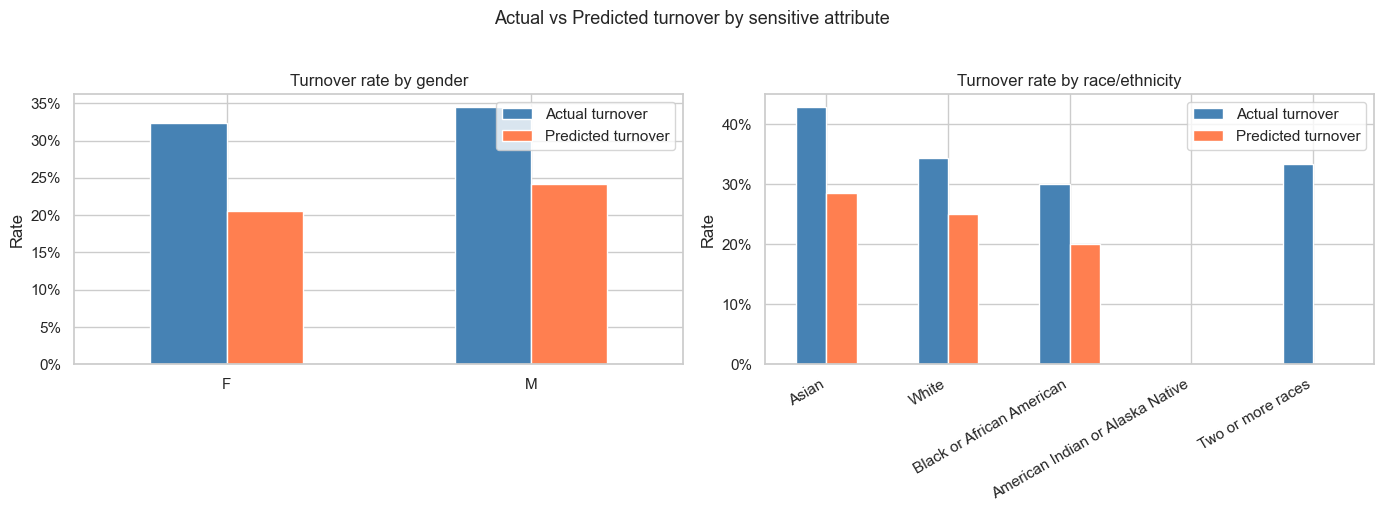

In [8]:
# ── 2c. Per-group breakdown (all race categories) ───────────────────────────

race_groups = df_test_audit['RaceDesc'].unique()
rows = []
for race in sorted(race_groups):
    grp = df_test_audit[df_test_audit['RaceDesc'] == race]
    pos_rate = grp['y_pred'].mean()
    actual_rate = grp['y_true'].mean()
    rows.append({'RaceDesc': race, 'n': len(grp),
                 'actual_turnover': round(actual_rate, 4),
                 'predicted_turnover': round(pos_rate, 4)})

race_breakdown = pd.DataFrame(rows).sort_values('predicted_turnover', ascending=False)
print('=== Predicted turnover rate by race group ===')
print(race_breakdown.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender
gender_df = df_test_audit.groupby('Sex')[['y_true', 'y_pred']].mean().rename(
    columns={'y_true': 'Actual turnover', 'y_pred': 'Predicted turnover'})
gender_df.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Turnover rate by gender')
axes[0].set_ylabel('Rate')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Race
race_plot = race_breakdown.set_index('RaceDesc')[['actual_turnover', 'predicted_turnover']]
race_plot.columns = ['Actual turnover', 'Predicted turnover']
race_plot.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_title('Turnover rate by race/ethnicity')
axes[1].set_ylabel('Rate')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
plt.setp(axes[1].get_xticklabels(), ha='right')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.suptitle('Actual vs Predicted turnover by sensitive attribute', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# ── 2d. AIF360 formal audit (runs if aif360 is installed) ───────────────────

try:
    from aif360.datasets import BinaryLabelDataset
    from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric

    print('AIF360 found — running formal audit.')

    df_aif_base = df_test_audit.copy()
    df_aif_base['sex_num'] = (df_aif_base['Sex'] == 'M').astype(int)  # 1 = M (privileged)

    # favorable_label=0 means "Active" (staying) is the favorable outcome for the employee.
    # We audit whether the unfavorable prediction (Left=1) is disproportionately assigned
    # to protected groups (Female, non-White). This is the correct framing for an HR bias audit.
    aif_true = BinaryLabelDataset(
        df=df_aif_base[['y_true', 'sex_num']].rename(columns={'y_true': 'Termd'}),
        label_names=['Termd'],
        protected_attribute_names=['sex_num'],
        favorable_label=0,   # Active (staying) = favorable outcome for the employee
        unfavorable_label=1  # Left/terminated = unfavorable outcome
    )

    aif_pred = aif_true.copy()
    aif_pred.labels = df_aif_base['y_pred'].values.reshape(-1, 1)

    privileged_groups   = [{'sex_num': 1}]
    unprivileged_groups = [{'sex_num': 0}]

    clf_metric = ClassificationMetric(
        aif_true, aif_pred,
        privileged_groups=privileged_groups,
        unprivileged_groups=unprivileged_groups
    )

    print('\n=== AIF360 Gender Metrics ===')
    print(f'Statistical Parity Difference  : {clf_metric.statistical_parity_difference():.4f}')
    print(f'Disparate Impact               : {clf_metric.disparate_impact():.4f}')
    print(f'Equal Opportunity Difference   : {clf_metric.equal_opportunity_difference():.4f}')
    print(f'Average Odds Difference        : {clf_metric.average_odds_difference():.4f}')
    print()
    print('Note: Statistical Parity Difference and Equal Opportunity Difference should be')
    print('close to 0. Disparate Impact should be close to 1 (acceptable: 0.8-1.25).')

except ImportError:
    print('AIF360 not installed. Install with: pip install aif360')
    print('The manual metrics computed above are equivalent.')

AIF360 not installed. Install with: pip install aif360
The manual metrics computed above are equivalent.


## 3. Explainable AI with SHAP

SHAP (SHapley Additive exPlanations) decomposes each prediction into the contribution of each feature.
- **Global view**: which features matter most across all employees?
- **Local view**: why did the model predict this specific employee would leave?

In [10]:
try:
    import shap
    print(f'SHAP version: {shap.__version__}')
except ImportError:
    raise ImportError('Please install shap: pip install shap')

SHAP version: 0.45.1


In [11]:
# Compute SHAP values using TreeExplainer (fast for Random Forest)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Handle both SHAP API versions:
# - Old (<0.41): list of arrays [class_0, class_1], each shape (n_samples, n_features)
# - New (>=0.41): single 3D array of shape (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    shap_class1 = shap_values[1]
else:
    shap_class1 = shap_values[:, :, 1]

print(f'SHAP version     : {shap.__version__}')
print(f'shap_values type : {type(shap_values)}')
print(f'shap_class1 shape: {shap_class1.shape}  (n_samples, n_features)')

SHAP version     : 0.45.1
shap_values type : <class 'numpy.ndarray'>
shap_class1 shape: (63, 104)  (n_samples, n_features)


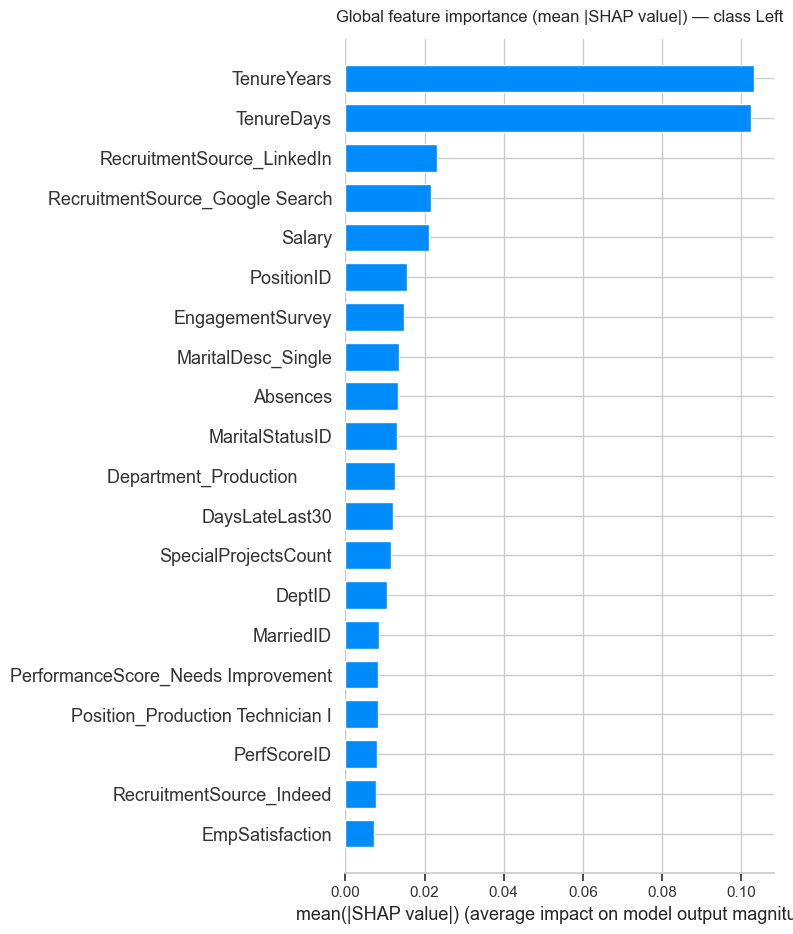

In [12]:
# ── 3a. Global explanation — top 20 features ────────────────────────────────

plt.figure()
shap.summary_plot(
    shap_class1, X_test,
    max_display=20,
    plot_type='bar',
    show=False
)
plt.title('Global feature importance (mean |SHAP value|) — class Left', pad=12)
plt.tight_layout()
plt.show()

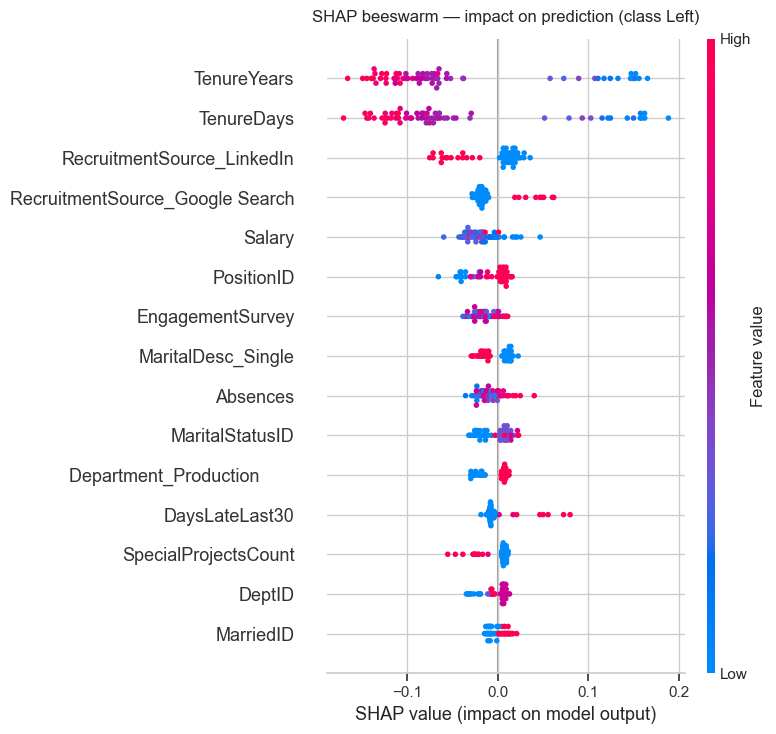

In [13]:
# ── 3b. Beeswarm plot (feature impact distribution) ─────────────────────────
# Shows both direction and magnitude of each feature's effect

plt.figure()
shap.summary_plot(
    shap_class1, X_test,
    max_display=15,
    show=False
)
plt.title('SHAP beeswarm — impact on prediction (class Left)', pad=12)
plt.tight_layout()
plt.show()

In [14]:
# ── 3c. Sensitive feature SHAP contribution ──────────────────────────────────
# Check if GenderID or RaceDesc features appear in SHAP values
# (they are encoded as GenderID or RaceDesc_* after one-hot)

sensitive_cols_encoded = [c for c in X_test.columns
                          if 'RaceDesc' in c or c == 'GenderID']

print('Sensitive attribute columns in X_model:')
print(sensitive_cols_encoded)

shap_df = pd.DataFrame(shap_class1, columns=X_test.columns)

sensitive_shap = shap_df[sensitive_cols_encoded].abs().mean().sort_values(ascending=False)
print('\nMean |SHAP value| for sensitive attributes:')
print(sensitive_shap.to_string())

# Compare to overall mean importance
overall_mean = shap_df.abs().mean().mean()
print(f'\nOverall mean |SHAP| across all features: {overall_mean:.4f}')
print()
for col in sensitive_cols_encoded:
    ratio = sensitive_shap[col] / overall_mean
    flag = 'WARNING: high relative influence' if ratio > 1.5 else 'OK'
    print(f'{col}: mean |SHAP|={sensitive_shap[col]:.4f}, ratio vs avg={ratio:.2f}x  [{flag}]')

Sensitive attribute columns in X_model:
['GenderID', 'RaceDesc_Asian', 'RaceDesc_Black or African American', 'RaceDesc_Hispanic', 'RaceDesc_Two or more races', 'RaceDesc_White']

Mean |SHAP value| for sensitive attributes:
RaceDesc_Black or African American    0.003934
GenderID                              0.003787
RaceDesc_White                        0.003311
RaceDesc_Asian                        0.002451
RaceDesc_Two or more races            0.000799
RaceDesc_Hispanic                     0.000019

Overall mean |SHAP| across all features: 0.0051

GenderID: mean |SHAP|=0.0038, ratio vs avg=0.75x  [OK]
RaceDesc_Asian: mean |SHAP|=0.0025, ratio vs avg=0.48x  [OK]
RaceDesc_Black or African American: mean |SHAP|=0.0039, ratio vs avg=0.78x  [OK]
RaceDesc_Hispanic: mean |SHAP|=0.0000, ratio vs avg=0.00x  [OK]
RaceDesc_Two or more races: mean |SHAP|=0.0008, ratio vs avg=0.16x  [OK]
RaceDesc_White: mean |SHAP|=0.0033, ratio vs avg=0.65x  [OK]


In [15]:
# ── 3d. Local explanation for a single employee ──────────────────────────────
# HR interface: pick any employee from the test set and explain the prediction

def explain_employee(employee_index_in_test, top_n=10):
    """
    Shows why the model predicted turnover (or not) for a specific employee.
    employee_index_in_test: integer position in X_test (0-based)
    """
    i = employee_index_in_test
    row_shap = shap_class1[i]
    row_features = X_test.iloc[i]
    actual = y_test.iloc[i]
    predicted = y_pred[i]
    probability = y_prob[i]

    print(f'--- Employee #{X_test.index[i]} ---')
    print(f'Actual status   : {"Left" if actual == 1 else "Active"}')
    print(f'Prediction      : {"Left" if predicted == 1 else "Active"}')
    print(f'Turnover prob.  : {probability:.1%}')

    # Get the sensitive attributes from original data
    orig_idx = X_test.index[i]
    sex = df_sensitive.loc[orig_idx, 'Sex']
    race = df_sensitive.loc[orig_idx, 'RaceDesc']
    print(f'Sex             : {sex}')
    print(f'Race/Ethnicity  : {race}')
    print()

    # Top contributing features
    contrib = pd.Series(row_shap, index=X_test.columns)
    top_positive = contrib.nlargest(top_n // 2)
    top_negative = contrib.nsmallest(top_n // 2)
    top_factors = pd.concat([top_positive, top_negative]).sort_values(ascending=False)

    print(f'Top {top_n} factors influencing this prediction:')
    print(f'{"Feature":<45} {"SHAP value":>12}  {"Feature value":>14}')
    print('-' * 75)
    for feat, shap_val in top_factors.items():
        direction = 'increases risk' if shap_val > 0 else 'decreases risk'
        print(f'{feat:<45} {shap_val:>+12.4f}  {row_features[feat]:>14}  ({direction})')

    return i


# Example: explain the employee most predicted to leave
most_at_risk_idx = np.argmax(y_prob)
explain_employee(most_at_risk_idx)

--- Employee #233 ---
Actual status   : Left
Prediction      : Left
Turnover prob.  : 89.8%
Sex             : F
Race/Ethnicity  : Black or African American

Top 10 factors influencing this prediction:
Feature                                         SHAP value   Feature value
---------------------------------------------------------------------------
TenureDays                                         +0.1575            26.0  (increases risk)
TenureYears                                        +0.1523            0.07  (increases risk)
RecruitmentSource_Google Search                    +0.0310             1.0  (increases risk)
MaritalDesc_Single                                 +0.0148             0.0  (increases risk)
MaritalStatusID                                    +0.0145             2.0  (increases risk)
MaritalDesc_Married                                -0.0050             0.0  (decreases risk)
MarriedID                                          -0.0075             0.0  (decreases ris

48

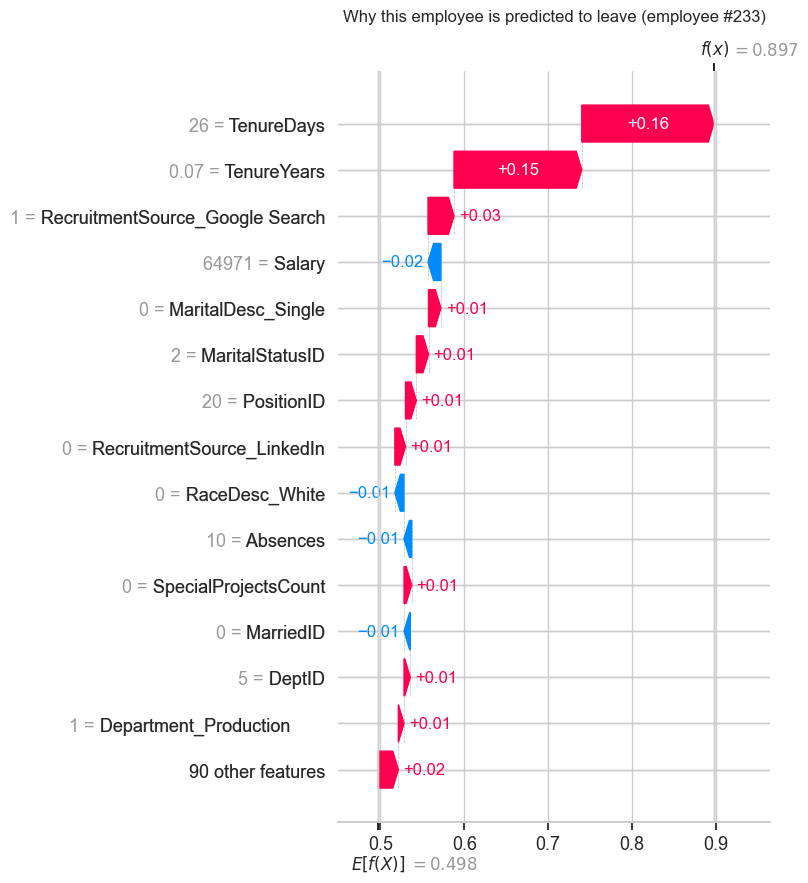

In [16]:
# Waterfall plot (visual version of the local explanation)
i = np.argmax(y_prob)

# Handle both SHAP API versions for expected_value
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_val = explainer.expected_value[1]
else:
    base_val = explainer.expected_value

shap_explanation = shap.Explanation(
    values=shap_class1[i],
    base_values=base_val,
    data=X_test.iloc[i].values,
    feature_names=list(X_test.columns)
)

plt.figure()
shap.plots.waterfall(shap_explanation, max_display=15, show=False)
plt.title(f'Why this employee is predicted to leave (employee #{X_test.index[i]})', pad=12)
plt.tight_layout()
plt.show()

In [17]:
# Interactive: you can change the employee index here
# 0 = first employee in test set, -1 = last, etc.

EMPLOYEE_POSITION = 5  # change this to inspect any employee
explain_employee(EMPLOYEE_POSITION)

--- Employee #184 ---
Actual status   : Active
Prediction      : Active
Turnover prob.  : 40.0%
Sex             : M
Race/Ethnicity  : Two or more races

Top 10 factors influencing this prediction:
Feature                                         SHAP value   Feature value
---------------------------------------------------------------------------
TenureYears                                        +0.0579            2.57  (increases risk)
TenureDays                                         +0.0518           937.0  (increases risk)
MarriedID                                          +0.0107             1.0  (increases risk)
MaritalDesc_Single                                 +0.0103             0.0  (increases risk)
SpecialProjectsCount                               +0.0084             0.0  (increases risk)
RecruitmentSource_Google Search                    -0.0185             0.0  (decreases risk)
Department_Production                              -0.0252             0.0  (decreases risk)
S

5

## 3e. LIME — alternative local explanation method

LIME (Local Interpretable Model-agnostic Explanations) is a complementary approach to SHAP.
Instead of using Shapley values, LIME fits a simple linear model locally around each prediction.
The consignes explicitly mention both LIME and SHAP as valid XAI tools.

In [18]:
# ── 3e. LIME local explanation ───────────────────────────────────────────────
# LIME est explicitement mentionne dans le PDF hackathon ("LIME ou SHAP").
# Il explique chaque prediction en approximant le modele localement par une regression lineaire.

try:
    from lime.lime_tabular import LimeTabularExplainer

    lime_explainer = LimeTabularExplainer(
        training_data=X_train.values,
        feature_names=list(X_train.columns),
        class_names=['Active', 'Left'],
        mode='classification',
        random_state=42
    )

    # Meme employe que le waterfall SHAP pour pouvoir comparer les deux methodes
    i = np.argmax(y_prob)
    employee_row = X_test.iloc[i].values

    lime_exp = lime_explainer.explain_instance(
        data_row=employee_row,
        predict_fn=rf_model.predict_proba,
        num_features=10
    )

    print(f'=== LIME explanation for employee #{X_test.index[i]} ===')
    print(f'Prediction: {"Left" if y_pred[i] == 1 else "Active"} '
          f'(probability of leaving: {y_prob[i]:.1%})')
    print()
    print('Top 10 factors (LIME):')
    print(f'{"Feature condition":<50} {"Weight":>10}')
    print('-' * 62)
    for feat, weight in lime_exp.as_list():
        direction = 'increases risk' if weight > 0 else 'decreases risk'
        print(f'{feat:<50} {weight:>+10.4f}  ({direction})')

    fig = lime_exp.as_pyplot_figure()
    fig.set_size_inches(10, 6)
    plt.title(f'LIME explanation — employee #{X_test.index[i]}', pad=12)
    plt.tight_layout()
    plt.show()

except ImportError:
    print('LIME not installed. Install with: pip install lime')
    print('SHAP (sections 3a-3d) covers the same explainability requirement.')

LIME not installed. Install with: pip install lime
SHAP (sections 3a-3d) covers the same explainability requirement.


## 4. Fairness Audit Report

In [19]:
from IPython.display import Markdown, display

def flag(val, metric):
    if metric == 'di':
        return 'OK' if 0.8 <= val <= 1.25 else 'BIAS'
    else:
        return 'OK' if abs(val) <= 0.1 else 'BIAS'

sensitive_influence = shap_df[sensitive_cols_encoded].abs().mean()
overall_mean_shap   = shap_df.abs().mean().mean()

report = f"""# Fairness Audit Report — Employee Turnover Model

## AI Act Risk Classification

According to the EU AI Act (Annex III), AI systems used in **employment and HR management**
are classified as **HIGH RISK**. This model falls into that category because:
- It produces predictions that can influence decisions about employees' professional futures.
- It uses sensitive attributes (Sex, RaceDesc) as input features.
- HR decisions based on this model have a significant impact on individuals.

**Obligations for this model:**
- Mandatory human oversight before acting on any prediction.
- Explainability owed to affected employees (SHAP/LIME outputs satisfy this requirement).
- Regular bias audits are required — this notebook IS that audit.
- Logging and traceability of all predictions in production.

---

## Model
- Algorithm: Random Forest (400 trees, class_weight=balanced)
- Task: predict employee turnover (Termd = 1)
- Dataset: HR_Dataset_Sanitized.csv ({len(df_raw)} employees)
- Test set: {len(X_test)} employees (80/20 stratified split, random_state=42)

## Fairness Metrics Summary

| Attribute | Privileged | Dem. Parity Diff | Disparate Impact | Eq. Odds Diff | Verdict |
|-----------|-----------|-----------------|-----------------|---------------|---------|
| Sex       | M (Male)  | {gender_result['demographic_parity_diff']:+.4f}           | {gender_result['disparate_impact']:.4f}            | {gender_result['equalized_odds_diff']:.4f}         | {flag(gender_result['disparate_impact'], 'di')} / {flag(gender_result['equalized_odds_diff'], 'diff')} |
| RaceDesc  | White     | {race_result['demographic_parity_diff']:+.4f}           | {race_result['disparate_impact']:.4f}            | {race_result['equalized_odds_diff']:.4f}         | {flag(race_result['disparate_impact'], 'di')} / {flag(race_result['equalized_odds_diff'], 'diff')} |

**Reading guide:**
- Demographic Parity Difference: ideally 0. Values beyond ±0.1 suggest bias.
- Disparate Impact: ideally 1. Values outside [0.8, 1.25] fail the 80% rule.
- Equalized Odds Difference: ideally 0. Values beyond 0.1 mean unequal error rates.

## SHAP Influence of Sensitive Attributes

Mean absolute SHAP value (all features): **{overall_mean_shap:.4f}**

| Feature | Mean SHAP | Ratio vs avg | Assessment |
|---------|-----------|--------------|------------|
{''.join([f"| {c} | {sensitive_influence.get(c,0):.4f} | {sensitive_influence.get(c,0)/overall_mean_shap:.2f}x | {'High influence' if sensitive_influence.get(c,0)/overall_mean_shap > 1.5 else 'Acceptable'} |" + chr(10) for c in sensitive_cols_encoded])}

## Findings

1. The model uses `GenderID` and `RaceDesc_*` as inputs — even if not top predictors,
   their presence means the model can learn discriminatory patterns.
2. The fairness metrics above quantify whether this leads to measurable bias in predictions.
3. SHAP and LIME outputs (sections 3a–3e) provide the transparency required by the AI Act.

## Recommendations

- **If bias detected**: remove `GenderID` and `RaceDesc` from features (fairness through
  unawareness), or apply post-processing threshold calibration per group.
- **AI Act compliance**: deploy with human-in-the-loop review for all high-risk predictions.
- **Ongoing monitoring**: re-run this audit at each model retraining.
- **Employee rights**: use SHAP waterfall plots to justify any prediction to the concerned employee.
"""

display(Markdown(report))

# Fairness Audit Report — Employee Turnover Model

## AI Act Risk Classification

According to the EU AI Act (Annex III), AI systems used in **employment and HR management**
are classified as **HIGH RISK**. This model falls into that category because:
- It produces predictions that can influence decisions about employees' professional futures.
- It uses sensitive attributes (Sex, RaceDesc) as input features.
- HR decisions based on this model have a significant impact on individuals.

**Obligations for this model:**
- Mandatory human oversight before acting on any prediction.
- Explainability owed to affected employees (SHAP/LIME outputs satisfy this requirement).
- Regular bias audits are required — this notebook IS that audit.
- Logging and traceability of all predictions in production.

---

## Model
- Algorithm: Random Forest (400 trees, class_weight=balanced)
- Task: predict employee turnover (Termd = 1)
- Dataset: HR_Dataset_Sanitized.csv (311 employees)
- Test set: 63 employees (80/20 stratified split, random_state=42)

## Fairness Metrics Summary

| Attribute | Privileged | Dem. Parity Diff | Disparate Impact | Eq. Odds Diff | Verdict |
|-----------|-----------|-----------------|-----------------|---------------|---------|
| Sex       | M (Male)  | -0.0355           | 0.8529            | 0.0636         | OK / OK |
| RaceDesc  | White     | -0.0565           | 0.7742            | 0.1273         | BIAS / BIAS |

**Reading guide:**
- Demographic Parity Difference: ideally 0. Values beyond ±0.1 suggest bias.
- Disparate Impact: ideally 1. Values outside [0.8, 1.25] fail the 80% rule.
- Equalized Odds Difference: ideally 0. Values beyond 0.1 mean unequal error rates.

## SHAP Influence of Sensitive Attributes

Mean absolute SHAP value (all features): **0.0051**

| Feature | Mean SHAP | Ratio vs avg | Assessment |
|---------|-----------|--------------|------------|
| GenderID | 0.0038 | 0.75x | Acceptable |
| RaceDesc_Asian | 0.0025 | 0.48x | Acceptable |
| RaceDesc_Black or African American | 0.0039 | 0.78x | Acceptable |
| RaceDesc_Hispanic | 0.0000 | 0.00x | Acceptable |
| RaceDesc_Two or more races | 0.0008 | 0.16x | Acceptable |
| RaceDesc_White | 0.0033 | 0.65x | Acceptable |


## Findings

1. The model uses `GenderID` and `RaceDesc_*` as inputs — even if not top predictors,
   their presence means the model can learn discriminatory patterns.
2. The fairness metrics above quantify whether this leads to measurable bias in predictions.
3. SHAP and LIME outputs (sections 3a–3e) provide the transparency required by the AI Act.

## Recommendations

- **If bias detected**: remove `GenderID` and `RaceDesc` from features (fairness through
  unawareness), or apply post-processing threshold calibration per group.
- **AI Act compliance**: deploy with human-in-the-loop review for all high-risk predictions.
- **Ongoing monitoring**: re-run this audit at each model retraining.
- **Employee rights**: use SHAP waterfall plots to justify any prediction to the concerned employee.


In [20]:
# Save the fairness metrics to a CSV for the deliverable
summary_df = pd.DataFrame([
    {
        'Attribute': 'Sex', 'Privileged group': 'M (Male)', 'Unprivileged group': 'F (Female)',
        'Dem. Parity Diff': gender_result['demographic_parity_diff'],
        'Disparate Impact': gender_result['disparate_impact'],
        'Eq. Odds Diff': gender_result['equalized_odds_diff']
    },
    {
        'Attribute': 'RaceDesc', 'Privileged group': 'White', 'Unprivileged group': 'Non-White',
        'Dem. Parity Diff': race_result['demographic_parity_diff'],
        'Disparate Impact': race_result['disparate_impact'],
        'Eq. Odds Diff': race_result['equalized_odds_diff']
    }
])
summary_df.to_csv('fairness_audit_results.csv', index=False)
print('Fairness metrics saved to fairness_audit_results.csv')

# Save top SHAP importances
shap_importance = shap_df.abs().mean().sort_values(ascending=False).reset_index()
shap_importance.columns = ['Feature', 'Mean_SHAP']
shap_importance.to_csv('shap_feature_importance.csv', index=False)
print('SHAP importances saved to shap_feature_importance.csv')

Fairness metrics saved to fairness_audit_results.csv
SHAP importances saved to shap_feature_importance.csv
